<a href="https://colab.research.google.com/github/maulanayusuff/praktikum_struktur_data/blob/main/struktur_data_pertemuan_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install networkx matplotlib

In [2]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def dijkstra_with_paths(graph, start): #fungsi dijkstra dengan input graf dan titik mulai
  distances= {node: float ("inf") for node in graph} #set jarak awal semua node jadi tak terhingga
  distances[start]= 0 #set jarak node awal jadi nol
  previous= {node: None for node in graph} #wadah kosong untuk mencatat rute sebelum node
  queue= [(0, start)] #antrean prioritas awal berisi (jarak, node)

  while queue: #looping selama antrean masih ada
    current_distance, current_node= heapq.heappop(queue) #ambil node dengan jarak paling pendek

    if current_distance > distances[current_node]: #jika jarak baru lebih besar dari yang tercatat
        continue #abaikan dan lanjut ke antrean berikutnya

    for neighbor, weight in graph[current_node].items(): #cek semua tetangga dan bobot jalurnya
      distance= current_distance + weight #hitung total jarak ke node tetangga
      if distance < distances[neighbor]: #jika rute baru ini lebih pendek
        distances[neighbor]= distance #perbarui catatan jarak terpendek tetangga
        previous[neighbor]= current_node #catat node asal yang dilewati tetangga
        heapq.heappush(queue, (distance, neighbor)) #masukkan rute baru ke antrean prioritas

  return distances, previous #kembalikan hasil jarak terpendek dan rutenya

In [3]:
def get_path(previous, target): #fungsi untuk melacak rute dari titik akhir ke titik awal
  path= [] #wadah kosong berbentuk list untuk menyimpan urutan rute
  while target is not None: #looping mundur selama node tujuan masih ada/tercatat
    path.insert(0, target) #masukkan node ke baris paling depan dalam list rute
    target= previous[target] #pindah ke node sebelumnya yang dilewati
  return path #kembalikan hasil urutan rute yang sudah lengkap

In [4]:
def visualize_graph(graph, path= None): #fungsi menggambar graf dan rute terpendeknya
  G= nx.DiGraph() #membuat objek graf berarah (directed graph) baru

  for node in graph: #looping setiap node di dalam graf
    for neighbor, weight in graph[node].items(): #looping tetangga dan bobot garisnya
      G.add_edge(node, neighbor, weight= weight) #menghubungkan node ke tetangga beserta bobotnya

  pos= nx.spring_layout(G) #mengatur posisi koordinat titik (layout) otomatis
  edge_labels= nx.get_edge_attributes(G, "weight") #mengambil semua data angka bobot dari garis

  plt.figure(figsize= (8, 6)) #mengatur ukuran bingkai gambar (lebar 8, tinggi 6)
  nx.draw(G, pos, with_labels= True, node_color= "lightblue", node_size= 2000, font_weight= "bold", arrows= True) #menggambar titik graf dengan warna biru muda berpanah
  nx.draw_networkx_edge_labels(G, pos, edge_labels= edge_labels) #menampilkan teks angka bobot di setiap garis

  if path and len (path) > 1: #jika rute terpendek ada dan isinya lebih dari 1 node
    path_edges = list (zip (path, path[1:])) #membuat pasangan titik yang saling terhubung dalam rute
    nx.draw_networkx_edges (G, pos, edgelist=path_edges, edge_color='red', width=3) #mewarnai garis rute terpendek dengan warna merah tebal

  plt.title("Visualisasi Graf dan Jalur Terpendek") #memberikan judul di atas gambar graf
  plt.axis('off') #menghilangkan garis koordinat X dan Y pada latar belakang
  plt.show () #menampilkan hasil gambar graf seutuhnya ke layar

Jarak dari A ke Z: 14
Jalur: A→B→D→E→Z


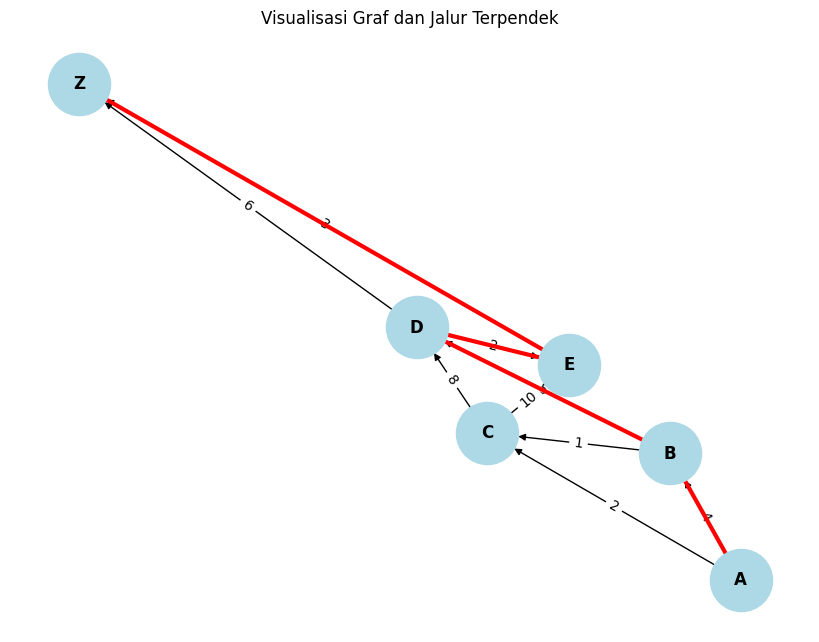

In [8]:
graph = { #membuat data dictionary sebagai struktur graf berbobot
    'A': {'B': 4, 'C': 2}, #node A terhubung ke B (bobot 4) dan C (bobot 2)
    'B': {'C': 1, 'D': 5}, #node B terhubung ke C (bobot 1) dan D (bobot 5)
    'C': {'D': 8, 'E': 10}, #node C terhubung ke D (bobot 8) dan E (bobot 10)
    'D': {'E': 2, 'Z': 6}, #node D terhubung ke E (bobot 2) dan Z (bobot 6)
    'E': {'Z': 3}, #node E terhubung ke Z (bobot 3)
    'Z': {} #node Z tidak terhubung ke mana-mana lagi (titik akhir)
}

start_node = 'A' #menentukan node A sebagai titik awal mulai
end_node = 'Z' #menentukan node Z sebagai titik tujuan akhir
distances, previous = dijkstra_with_paths (graph, start_node) #menjalankan fungsi dijkstra untuk mencari semua jarak dan rute

shortest_path = get_path (previous, end_node) #melacak rute terpendek khusus dari node A ke node Z
print(f"Jarak dari {start_node} ke {end_node}: {distances [end_node]}") #mencetak total angka jarak terpendek ke layar
print (f"Jalur: {'→'.join (shortest_path)}") #mencetak urutan rute perjalanan yang dipisahkan tanda panah

visualize_graph(graph, path=shortest_path) #menggambar dan menampilkan gambar graf beserta rute merahnya ke layar

Jarak dari A ke Z: 14
Jalur: A→B→D→E→Z


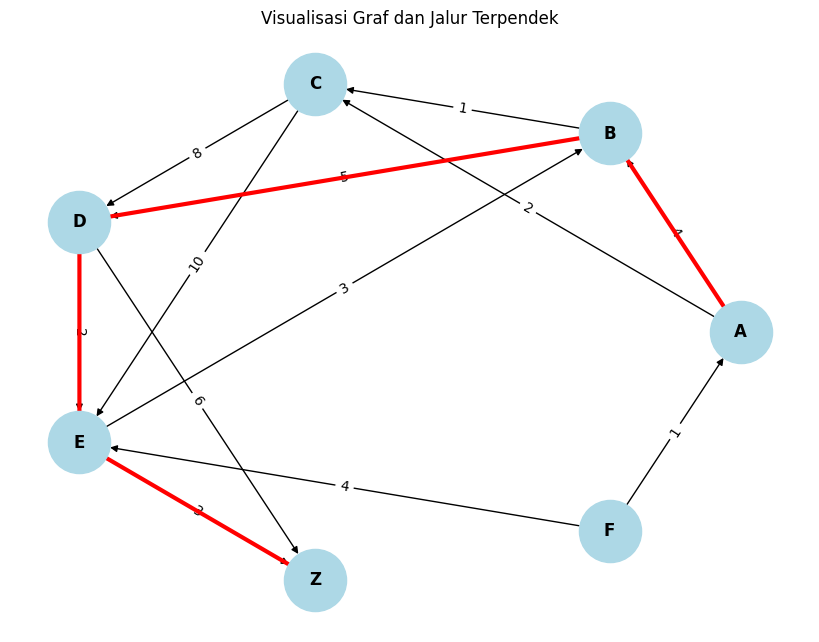

In [11]:
#tugas

import heapq #mengambil modul antrean prioritas otomatis
import networkx as nx #mengambil library pembuat graf
import matplotlib.pyplot as plt #mengambil library visualisasi graf

def dijkstra_with_paths(graph, start): #fungsi dijkstra mencari jarak dan rute terpendek
  distances= {node: float ("inf") for node in graph} #set jarak awal semua node jadi tak terhingga
  distances[start]= 0 #set jarak node awal jadi nol
  previous= {node: None for node in graph} #wadah kosong mencatat rute sebelum node
  queue= [(0, start)] #antrean prioritas awal berisi (jarak, node)

  while queue: #looping selama antrean masih ada
    current_distance, current_node= heapq.heappop(queue) #ambil node jarak paling pendek

    if current_distance > distances[current_node]: #jika jarak baru lebih besar dari yang tercatat
        continue #abaikan dan lanjut ke antrean berikutnya

    for neighbor, weight in graph[current_node].items(): #cek semua tetangga dan bobot jalurnya
      distance= current_distance + weight #hitung total jarak ke node tetangga
      if distance < distances[neighbor]: #jika rute baru ini lebih pendek
        distances[neighbor]= distance #perbarui catatan jarak terpendek tetangga
        previous[neighbor]= current_node #catat node asal sebelum tetangga
        heapq.heappush(queue, (distance, neighbor)) #masukkan rute baru ke antrean prioritas

  return distances, previous #kembalikan hasil jarak terpendek dan rutenya

def get_path(previous, target): #fungsi melacak rute mundur dari akhir ke awal
  path= [] #wadah kosong list urutan rute
  while target is not None: #looping mundur selama node tujuan tercatat
    path.insert(0, target) #masukkan node ke baris paling depan list
    target= previous[target] #pindah ke node sebelumnya yang dilewati
  return path #kembalikan hasil urutan rute lengkap

def visualize_graph(graph, path= None, layout=None): #fungsi menggambar graf, rute, dan pilihan layout
  G= nx.DiGraph() #membuat objek graf berarah baru

  for node in graph: #looping setiap node di dalam graf
    for neighbor, weight in graph[node].items(): #looping tetangga dan bobot garisnya
      G.add_edge(node, neighbor, weight= weight) #hubungkan node ke tetangga beserta bobotnya

  if layout == 'circular': #jika parameter layout diisi 'circular'
      pos = nx.circular_layout(G) #atur posisi node melingkar beraturan
  elif layout == 'kamada_kawai': #jika parameter layout diisi 'kamada_kawai'
      pos = nx.kamada_kawai_layout(G) #atur posisi node berdasarkan kekuatan pegas/jarak
  else: #jika tidak memilih layout di atas
      pos = nx.spring_layout(G) #atur posisi node acak menyebar otomatis

  edge_labels= nx.get_edge_attributes(G, "weight") #mengambil data angka bobot dari garis

  plt.figure(figsize= (8, 6)) #mengatur ukuran bingkai gambar graf
  nx.draw(G, pos, with_labels= True, node_color= "lightblue", node_size= 2000, font_weight= "bold", arrows= True) #gambar titik graf biru muda berpanah
  nx.draw_networkx_edge_labels(G, pos, edge_labels= edge_labels) #tampilkan teks angka bobot di garis

  if path and len (path) > 1: #jika rute terpendek ada dan valid
    path_edges = list (zip (path, path[1:])) #buat pasangan titik yang terhubung dalam rute
    nx.draw_networkx_edges (G, pos, edgelist=path_edges, edge_color='red', width=3) #warnai jalur terpendek dengan warna merah tebal

  plt.title("Visualisasi Graf dan Jalur Terpendek") #memberikan judul gambar graf
  plt.axis('off') #menghilangkan garis koordinat latar belakang
  plt.show () #menampilkan gambar graf seutuhnya ke layar

graph = { #membuat data struktur graf baru dengan tambahan node
    'A': {'B': 4, 'C': 2}, #node A ke B (bobot 4) dan C (bobot 2)
    'B': {'C': 1, 'D': 5}, #node B ke C (bobot 1) dan D (bobot 5)
    'C': {'D': 8, 'E': 10}, #node C ke D (bobot 8) dan E (bobot 10)
    'D': {'E': 2, 'Z': 6}, #node D ke E (bobot 2) dan Z (bobot 6)
    'E': {'Z': 3, 'B': 3},  #node E ke Z (bobot 3) dan memutar balik ke B (bobot 3)
    'Z': {}, #node Z titik tujuan akhir kosong
    'F': {'A': 1, 'E': 4}  #node F baru terhubung ke A (bobot 1) dan E (bobot 4)
}

start_node = 'A' #menentukan titik awal mulai dari A
end_node = 'Z' #menentukan titik tujuan akhir di Z
distances, previous = dijkstra_with_paths (graph, start_node) #jalankan dijkstra untuk hitung jarak dan rute

shortest_path = get_path (previous, end_node) #lacak rute terpendek dari A ke Z
print(f"Jarak dari {start_node} ke {end_node}: {distances [end_node]}") #cetak total angka jarak terpendek ke layar
print (f"Jalur: {'→'.join (shortest_path)}") #cetak urutan rute dipisah tanda panah

visualize_graph(graph, path=shortest_path, layout='circular') #tampilkan grafik dengan bentuk posisi melingkar